# Taller 05 — Clustering DBSCAN

**Asignatura:** Inteligencia Artificial — ELP 8012  
**Integrantes:** *Complete aquí los nombres de los integrantes*  
**Universidad del Norte**

## Objetivo

Diseñar e implementar DBSCAN para encontrar grupos de forma arbitraria en datos sintéticos bidimensionales. Se construye una figura original con **20 grupos amorfos**, se agregan *outliers* uniformes, se estudian gráficos de k-distancia para seleccionar `eps` y `MinPts`, y se evalúa el resultado con dos métricas: **Adjusted Rand Index (ARI)** y **coeficiente de silueta**.

La implementación de DBSCAN es propia; `scikit-learn` se usa únicamente para las métricas de evaluación.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from sklearn.metrics import adjusted_rand_score, silhouette_score

SEED = 42
rng = np.random.default_rng(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)

## 1. Construcción de la figura y los datos

La figura se diseña sobre una cuadrícula de 5 columnas por 4 filas. En cada celda se genera una curva amorfa de uno de cuatro tipos: anillo deformado, arco/luna, espiral corta o curva ondulada. Cada grupo recibe rotación, escala y ruido propios; por tanto, no se trata de nubes gaussianas circulares. La separación entre celdas permite que DBSCAN identifique la conectividad local sin fusionar grupos distintos.

Las etiquetas verdaderas se conservan **solo para evaluar**. Además, se añaden puntos uniformes en el rectángulo completo con etiqueta `-1`, que representan ruido real.

In [2]:
def forma_amorfa(tipo, n, rng):
    t = rng.uniform(0, 1, n)
    if tipo == 0:                         # anillo deformado
        a = 2 * np.pi * t
        r = 1 + 0.22*np.sin(3*a) + 0.10*np.sin(7*a)
        p = np.c_[r*np.cos(a), 0.72*r*np.sin(a)]
    elif tipo == 1:                       # luna / arco grueso
        a = 1.15*np.pi*t - 0.08*np.pi
        p = np.c_[1.25*np.cos(a), 0.85*np.sin(a)]
    elif tipo == 2:                       # espiral corta
        a = 2.5*np.pi*t
        r = 0.35 + 0.82*t
        p = np.c_[r*np.cos(a), 0.72*r*np.sin(a)]
    else:                                 # cinta sinusoidal
        x = 2.2*(t - .5)
        p = np.c_[x, 0.55*np.sin(2.2*np.pi*t)]
    p += rng.normal(0, 0.075, p.shape)
    return p

grupos, etiquetas = [], []
centros = [(5*c, 5*r) for r in range(4) for c in range(5)]
for i, centro in enumerate(centros):
    p = forma_amorfa(i % 4, 110, rng)
    ang = rng.uniform(-0.45, 0.45)
    R = np.array([[np.cos(ang), -np.sin(ang)],
                  [np.sin(ang),  np.cos(ang)]])
    escala = rng.uniform(0.82, 1.08, 2)
    p = (p * escala) @ R.T + np.asarray(centro)
    grupos.append(p)
    etiquetas.extend([i] * len(p))

X_grupos = np.vstack(grupos)
margen = 1.8
lim_inf = X_grupos.min(axis=0) - margen
lim_sup = X_grupos.max(axis=0) + margen
outliers = rng.uniform(lim_inf, lim_sup, size=(180, 2))

X = np.vstack([X_grupos, outliers])
y_true = np.r_[np.asarray(etiquetas), np.full(len(outliers), -1)]
orden = rng.permutation(len(X))
X, y_true = X[orden], y_true[orden]

print(f'Total: {len(X)} puntos | grupos: {len(centros)} | outliers: {sum(y_true == -1)}')

Total: 2380 puntos | grupos: 20 | outliers: 180


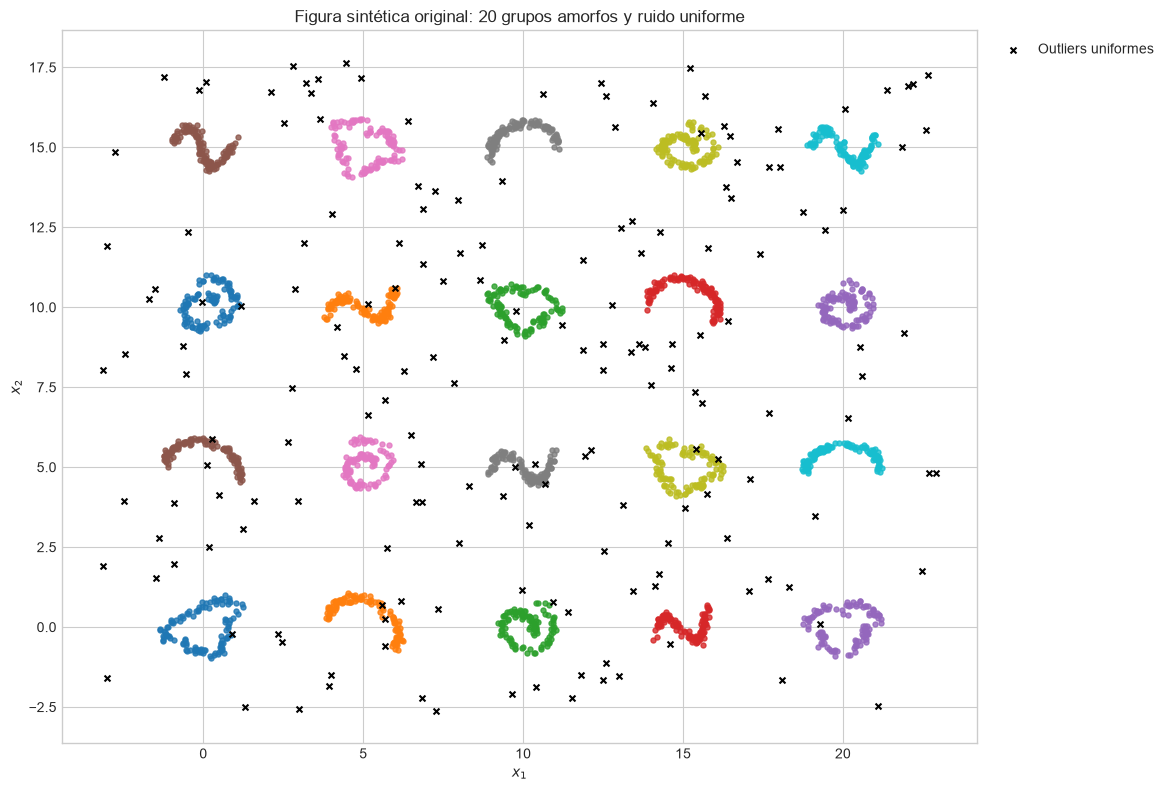

In [3]:
fig, ax = plt.subplots(figsize=(12, 8))
for etiqueta in range(20):
    m = y_true == etiqueta
    ax.scatter(X[m, 0], X[m, 1], s=13, alpha=.8)
m = y_true == -1
ax.scatter(X[m, 0], X[m, 1], s=18, c='black', marker='x', label='Outliers uniformes')
ax.set(title='Figura sintética original: 20 grupos amorfos y ruido uniforme',
       xlabel='$x_1$', ylabel='$x_2$', aspect='equal')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

## 2. Implementación de DBSCAN

Para cada punto se calcula su vecindad cerrada $N_\varepsilon(p)=\{q:d(p,q)\leq\varepsilon\}$. Un punto es **núcleo** si su vecindad contiene al menos `MinPts` puntos (incluyéndose a sí mismo). Cada grupo se expande por búsqueda en anchura desde un núcleo; los puntos alcanzables que no son núcleo quedan como frontera. Los puntos nunca alcanzados se etiquetan `-1` (ruido).

La matriz de distancias se calcula una sola vez. Esta solución $O(n^2)$ es clara y adecuada para el tamaño del taller; en conjuntos masivos convendría un índice espacial como KD-tree.

In [4]:
def matriz_distancias(X):
    delta = X[:, None, :] - X[None, :, :]
    return np.sqrt(np.sum(delta**2, axis=2))

D = matriz_distancias(X)

def dbscan_propio(D, eps, min_pts):
    n = len(D)
    vecinos = [np.flatnonzero(D[i] <= eps) for i in range(n)]
    es_nucleo = np.array([len(v) >= min_pts for v in vecinos])
    NO_VISITADO, RUIDO = -99, -1
    labels = np.full(n, NO_VISITADO, dtype=int)
    cluster_id = 0

    for i in range(n):
        if labels[i] != NO_VISITADO:
            continue
        if not es_nucleo[i]:
            labels[i] = RUIDO
            continue

        labels[i] = cluster_id
        cola = deque(vecinos[i].tolist())
        en_cola = np.zeros(n, dtype=bool)
        en_cola[vecinos[i]] = True
        while cola:
            j = cola.popleft()
            if labels[j] == RUIDO:        # un ruido previo pasa a ser frontera
                labels[j] = cluster_id
            if labels[j] != NO_VISITADO:
                continue
            labels[j] = cluster_id
            if es_nucleo[j]:
                nuevos = vecinos[j][~en_cola[vecinos[j]]]
                cola.extend(nuevos.tolist())
                en_cola[nuevos] = True
        cluster_id += 1
    return labels, es_nucleo

# Pruebas mínimas de propiedades de la implementación
toy = np.array([[0.,0.], [.1,0.], [0.,.1], [4.,4.]])
toy_labels, toy_core = dbscan_propio(matriz_distancias(toy), eps=.2, min_pts=3)
assert len(set(toy_labels[toy_labels >= 0])) == 1
assert toy_labels[-1] == -1 and toy_core[:3].all()
print('Pruebas internas superadas.')

Pruebas internas superadas.


## 3. Selección de hiperparámetros con k-distancia

`MinPts` controla cuántos vecinos se exigen para considerar una zona densa. En 2D suele ser razonable explorar valores desde 4 en adelante; aquí se comparan **5, 8, 12 y 16**, ya que hay suficientes puntos por grupo y existe ruido uniforme.

Para cada valor se ordena la distancia al vecino número `k = MinPts` (contando al propio punto como el primero). El “codo” se estima automáticamente como el punto de mayor desviación respecto de la recta que une los extremos de la curva normalizada. Este criterio sirve como referencia reproducible y luego se valida con estabilidad y métricas; el codo no es una verdad única.

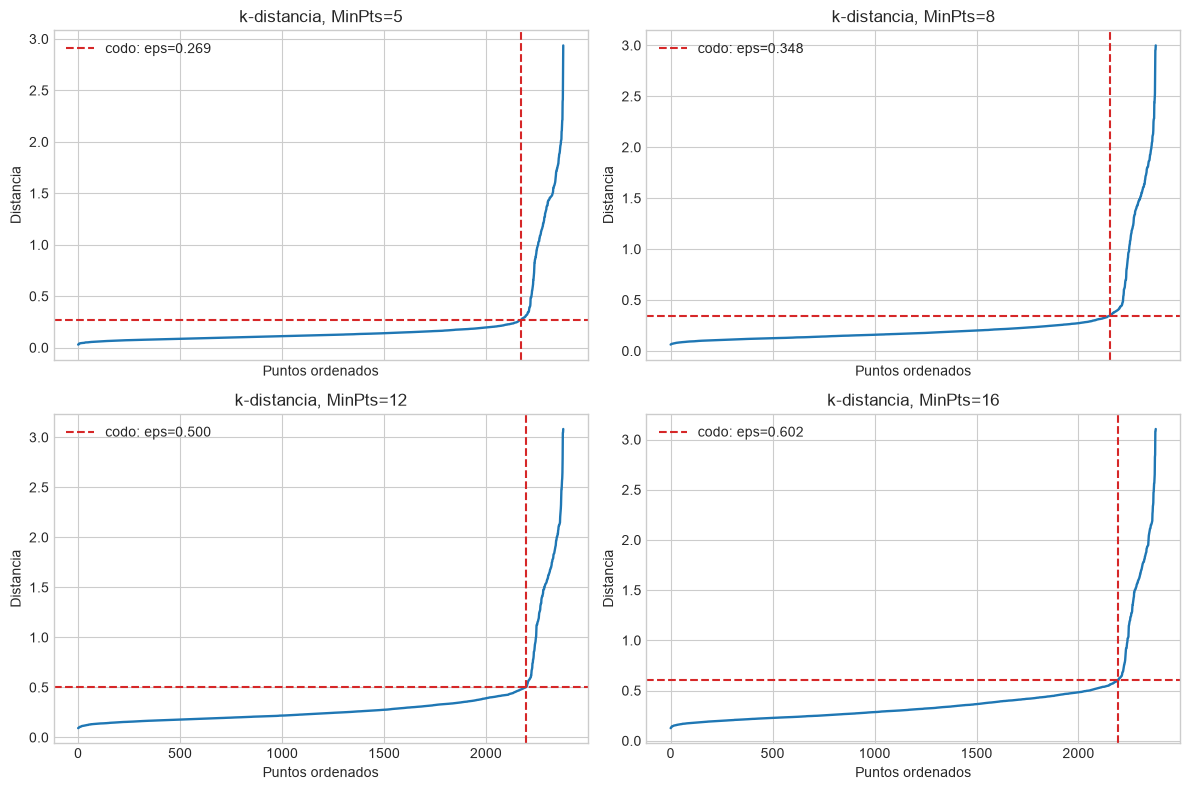

Epsilon sugerido por cada curva: {5: np.float64(0.269), 8: np.float64(0.348), 12: np.float64(0.5), 16: np.float64(0.602)}


In [5]:
def curva_k_distancia(D, k):
    # La primera distancia es 0 (el propio punto); k-1 selecciona el vecino k.
    return np.sort(np.partition(D, k-1, axis=1)[:, k-1])

def indice_codo(curva):
    x = np.linspace(0, 1, len(curva))
    y = (curva - curva.min()) / (curva.max() - curva.min())
    # Para una curva convexa creciente, el codo maximiza la distancia bajo la diagonal.
    return int(np.argmax(x - y))

candidatos_minpts = [5, 8, 12, 16]
codos = {}
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for k, ax in zip(candidatos_minpts, axs.ravel()):
    curva = curva_k_distancia(D, k)
    idx = indice_codo(curva)
    codos[k] = curva[idx]
    ax.plot(curva, lw=1.7)
    ax.axvline(idx, color='tab:red', ls='--')
    ax.axhline(curva[idx], color='tab:red', ls='--',
               label=f'codo: eps={curva[idx]:.3f}')
    ax.set(title=f'k-distancia, MinPts={k}', xlabel='Puntos ordenados', ylabel='Distancia')
    ax.legend()
plt.tight_layout()
plt.show()
print('Epsilon sugerido por cada curva:', {k: round(v, 3) for k, v in codos.items()})

### Validación conjunta de `eps` y `MinPts`

Una curva k-distancia ayuda a proponer `eps`, pero distintos codos pueden producir fragmentación o fusiones. Para no escoger visualmente a conveniencia, se evalúa una pequeña vecindad (90%, 100% y 110% del codo) para cada `MinPts`. Se reportan número de grupos, proporción de ruido, ARI y silueta. La selección final maximiza ARI; esto es válido en este experimento sintético porque se conocen las etiquetas generadoras. En un problema real sin etiquetas se elegiría con silueta, estabilidad y conocimiento del dominio.

In [6]:
resultados = []
for min_pts in candidatos_minpts:
    for factor in [0.90, 1.00, 1.10]:
        eps = codos[min_pts] * factor
        pred, core = dbscan_propio(D, eps, min_pts)
        n_clusters = len(set(pred)) - (-1 in pred)
        mask = pred != -1
        sil = (silhouette_score(X[mask], pred[mask])
               if n_clusters >= 2 and mask.sum() > n_clusters else np.nan)
        ari = adjusted_rand_score(y_true, pred)
        resultados.append((min_pts, eps, n_clusters, np.mean(pred == -1), ari, sil))

print(f"{'MinPts':>6} {'eps':>7} {'grupos':>7} {'ruido':>8} {'ARI':>8} {'silueta':>9}")
for fila in resultados:
    print(f'{fila[0]:6d} {fila[1]:7.3f} {fila[2]:7d} {fila[3]:8.2%} {fila[4]:8.3f} {fila[5]:9.3f}')

mejor = max(resultados, key=lambda r: r[4])
MIN_PTS, EPS = mejor[0], mejor[1]
print(f'\nSelección final: MinPts={MIN_PTS}, eps={EPS:.3f}')

MinPts     eps  grupos    ruido      ARI   silueta
     5   0.242      35    7.31%    0.875     0.581
     5   0.269      25    6.89%    0.944     0.669
     5   0.296      21    6.85%    0.972     0.756
     8   0.313      28    7.27%    0.913     0.680
     8   0.348      22    6.76%    0.956     0.752
     8   0.383      21    6.76%    0.968     0.766
    12   0.450      20    6.47%    0.972     0.781
    12   0.500      20    6.26%    0.967     0.780
    12   0.550      20    6.22%    0.966     0.780
    16   0.542      20    6.34%    0.969     0.781
    16   0.602      20    6.13%    0.964     0.780
    16   0.662      20    6.05%    0.962     0.780

Selección final: MinPts=12, eps=0.450


## 4. Resultado del agrupamiento

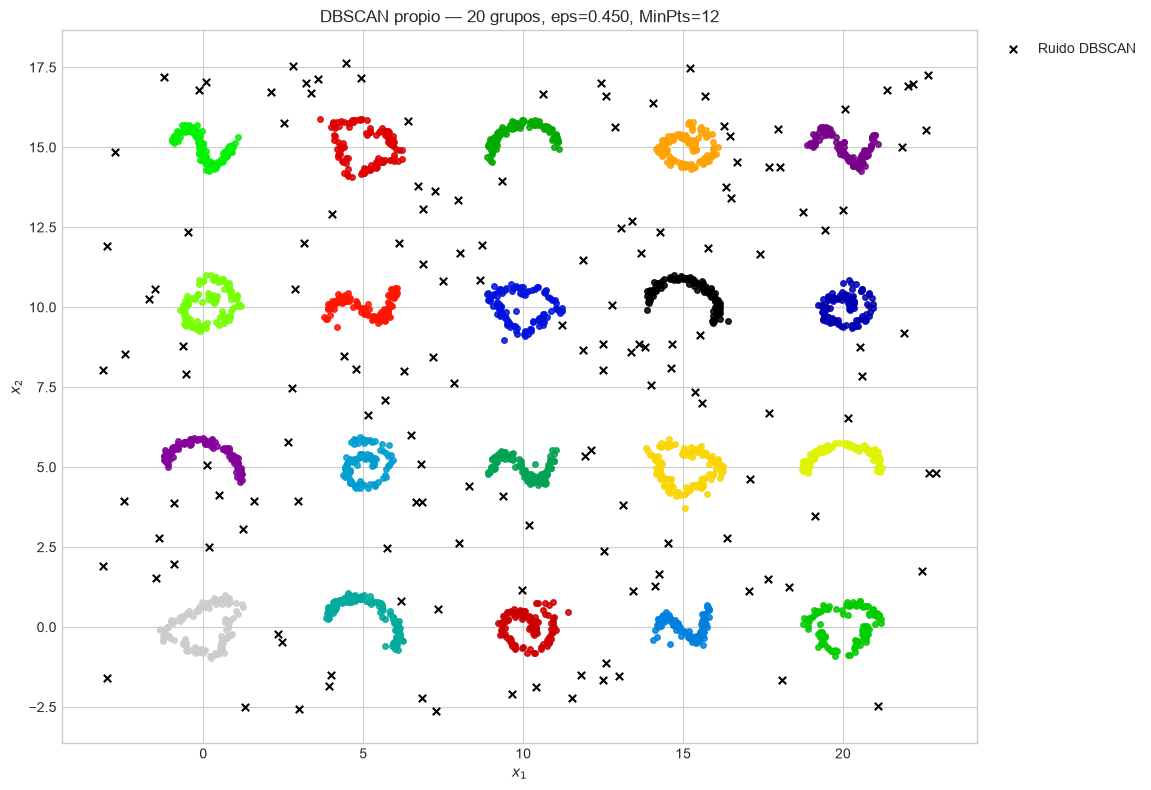

Puntos núcleo: 2139
Puntos de frontera: 87
Ruido detectado: 154 (6.47%)


In [7]:
y_pred, es_nucleo = dbscan_propio(D, EPS, MIN_PTS)
n_clusters = len(set(y_pred)) - (-1 in y_pred)

fig, ax = plt.subplots(figsize=(12, 8))
colores = plt.cm.nipy_spectral(np.linspace(0, 1, max(n_clusters, 1)))
for c, color in enumerate(colores):
    m = y_pred == c
    ax.scatter(X[m, 0], X[m, 1], s=16, color=color, alpha=.85)
ruido = y_pred == -1
ax.scatter(X[ruido, 0], X[ruido, 1], s=28, c='black', marker='x', label='Ruido DBSCAN')
ax.set(title=f'DBSCAN propio — {n_clusters} grupos, eps={EPS:.3f}, MinPts={MIN_PTS}',
       xlabel='$x_1$', ylabel='$x_2$', aspect='equal')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

print(f'Puntos núcleo: {es_nucleo.sum()}')
print(f'Puntos de frontera: {sum((y_pred != -1) & ~es_nucleo)}')
print(f'Ruido detectado: {sum(ruido)} ({ruido.mean():.2%})')

## 5. Evaluación

Se emplean dos enfoques complementarios:

1. **Adjusted Rand Index (ARI, externo):** compara pares de puntos entre la partición verdadera y la predicha, corrigiendo el acuerdo esperado por azar. Es invariante a los números asignados a cada grupo. Su máximo es 1; valores cercanos a 0 indican acuerdo aleatorio. Aquí se incluye `-1` como la clase verdadera de outliers.
2. **Silueta (interno):** para cada punto contrasta cohesión dentro de su grupo con separación respecto al grupo vecino. Va de -1 a 1 y valores mayores son mejores. Se calcula sobre los puntos asignados a grupos, excluyendo ruido, porque `-1` en DBSCAN no representa un único grupo compacto.

Además se muestra precisión/recobrado para ruido como diagnóstico, sin contarla como una de las dos métricas principales.

In [8]:
ari = adjusted_rand_score(y_true, y_pred)
mask = y_pred != -1
sil = silhouette_score(X[mask], y_pred[mask])

verdadero_ruido = y_true == -1
predicho_ruido = y_pred == -1
tp = np.sum(verdadero_ruido & predicho_ruido)
precision_ruido = tp / max(np.sum(predicho_ruido), 1)
recobrado_ruido = tp / np.sum(verdadero_ruido)

print(f'Adjusted Rand Index: {ari:.4f}')
print(f'Coeficiente de silueta (sin ruido): {sil:.4f}')
print(f'Precisión al detectar ruido: {precision_ruido:.2%}')
print(f'Recobrado de outliers: {recobrado_ruido:.2%}')
print(f'Grupos verdaderos / encontrados: 20 / {n_clusters}')

Adjusted Rand Index: 0.9722
Coeficiente de silueta (sin ruido): 0.7811
Precisión al detectar ruido: 100.00%
Recobrado de outliers: 85.56%
Grupos verdaderos / encontrados: 20 / 20


## 6. Conclusiones

- DBSCAN recupera estructuras no convexas porque forma componentes por conectividad de densidad, sin imponer centroides ni geometría esférica.
- Los gráficos de k-distancia proporcionan candidatos reproducibles para `eps`; explorar varios `MinPts` evita depender de una sola elección visual.
- ARI mide la recuperación de la partición generadora, mientras que silueta mide cohesión/separación geométrica. Sus respuestas no tienen por qué ser idénticas, por lo que juntas ofrecen una lectura más completa.
- Los outliers uniformes que caen accidentalmente dentro de una región densa son indistinguibles de puntos del grupo usando solo densidad local. Por eso el recobrado del ruido puede ser menor que 100% aun con buenos grupos.
- La semilla fija hace reproducible todo el experimento. Cambiar `SEED` permite comprobar estabilidad.

### Referencias

- Ester, M., Kriegel, H.-P., Sander, J. y Xu, X. (1996). *A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise*.
- Scikit-learn. *Clustering performance evaluation* y documentación de `sklearn.metrics` (consultadas como guía conceptual para las métricas).